🎯 Starting Agile Sprint 1: Baseline Model Training
✅ Data loaded successfully! Shape: (7043, 20)
🎯 Initializing Baseline Model Training...
🧹 Preparing data for modeling...
📋 Categorical columns to encode: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
   ✅ Encoded: gender - 2 categories
   ✅ Encoded: SeniorCitizen - 2 categories
   ✅ Encoded: Partner - 2 categories
   ✅ Encoded: Dependents - 2 categories
   ✅ Encoded: PhoneService - 2 categories
   ✅ Encoded: MultipleLines - 3 categories
   ✅ Encoded: InternetService - 3 categories
   ✅ Encoded: OnlineSecurity - 3 categories
   ✅ Encoded: OnlineBackup - 3 categories
   ✅ Encoded: DeviceProtection - 3 categories
   ✅ Encoded: TechSupport - 3 categories
   ✅ Encoded: StreamingTV - 3 categories
   ✅ Encoded: StreamingMovies - 3 cate

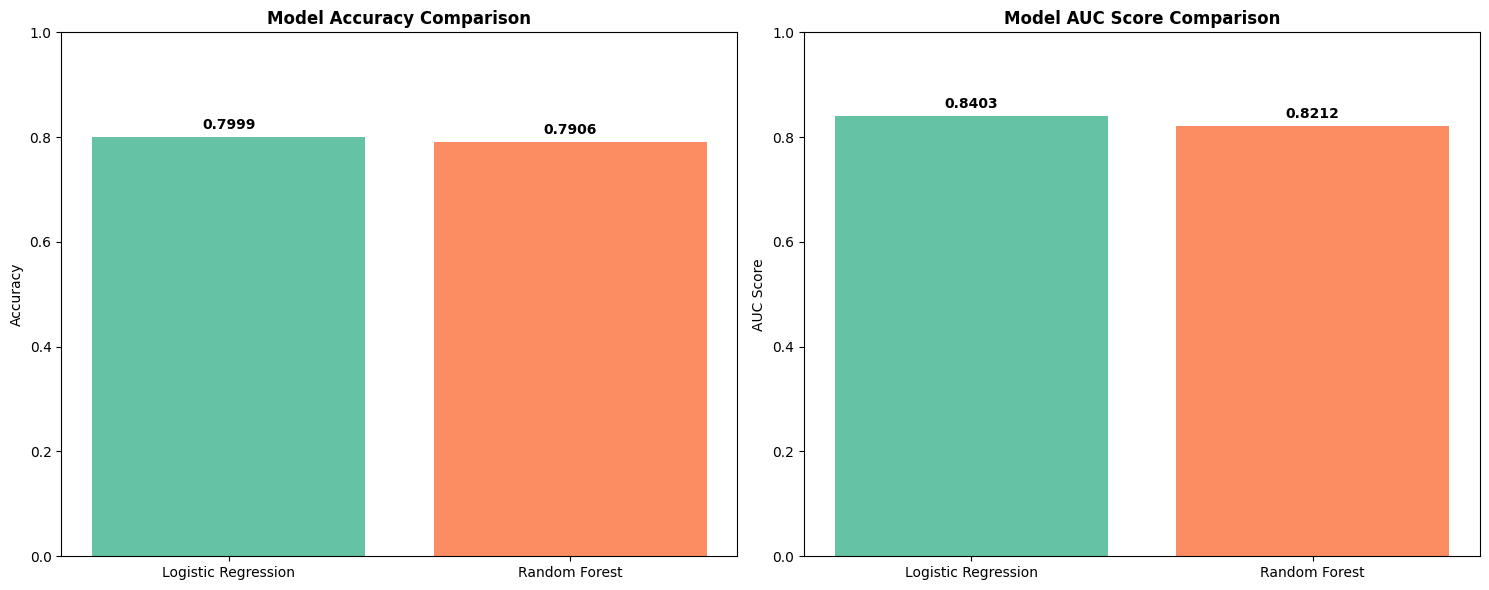

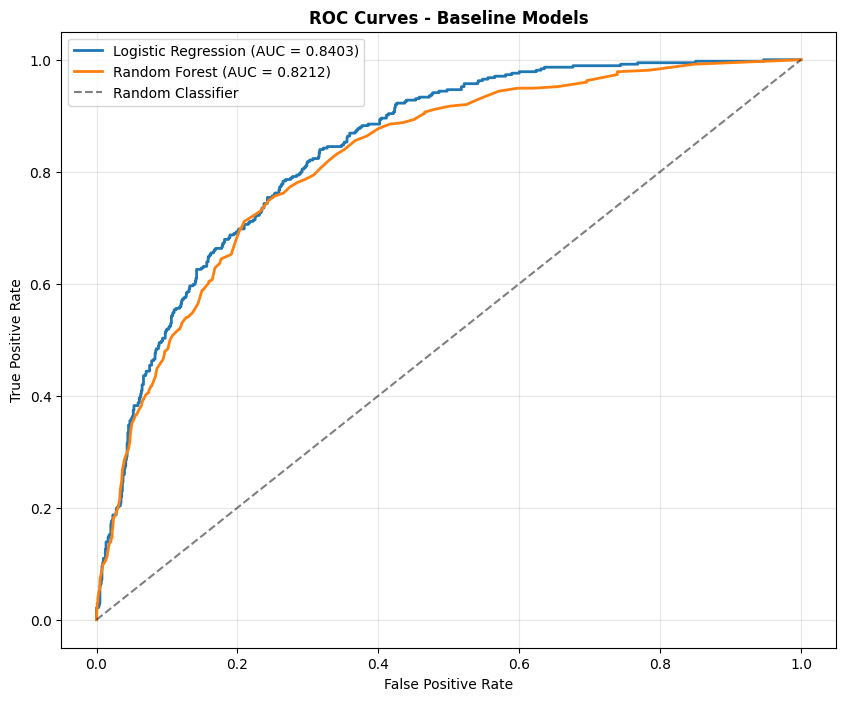


🏆 BEST MODEL: Logistic Regression
Accuracy: 0.7999
AUC Score: 0.8403

📋 Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.64      0.55      0.59       374

    accuracy                           0.80      1409
   macro avg       0.74      0.72      0.73      1409
weighted avg       0.79      0.80      0.79      1409



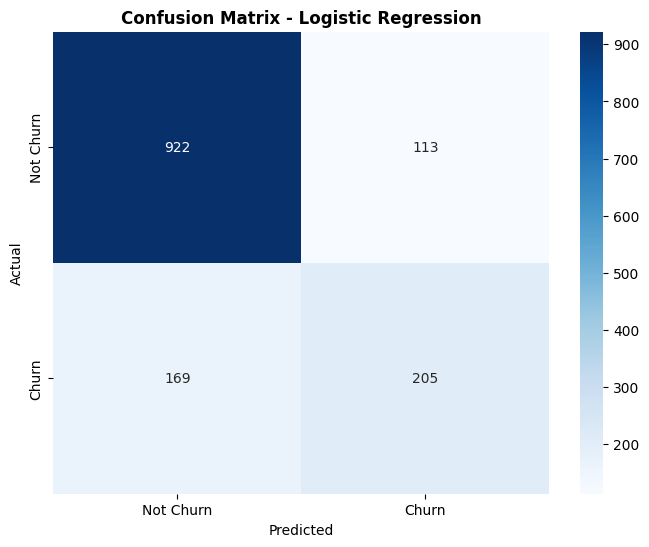


🎉 SPRINT 1 COMPLETED SUCCESSFULLY!
✅ Data Processing - Completed
✅ Exploratory Data Analysis - Completed
✅ Baseline Models - Completed
📊 Models saved in: models/trained_models/
📈 Visualizations saved in: models/model_performance/

🚀 READY FOR SPRINT 2: Feature Engineering & Advanced Models


In [1]:
# notebooks/02_baseline_model.ipynb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix, 
                           accuracy_score, roc_auc_score, roc_curve)
import joblib
import warnings
warnings.filterwarnings('ignore')

print("🎯 Starting Agile Sprint 1: Baseline Model Training")
print("=" * 60)

# Load cleaned data
df = pd.read_csv('../data/processed/cleaned_churn_data.csv')
print(f"✅ Data loaded successfully! Shape: {df.shape}")

class BaselineModelTrainer:
    def __init__(self, data):
        self.df = data
        self.preprocessor = None
        self.models = {}
        self.results = {}
        
    def prepare_data(self):
        """Prepare data for machine learning"""
        print("🧹 Preparing data for modeling...")
        
        df_encoded = self.df.copy()
        
        # Encode categorical variables
        categorical_cols = df_encoded.select_dtypes(include=['object']).columns
        print(f"📋 Categorical columns to encode: {list(categorical_cols)}")
        
        self.label_encoders = {}
        for col in categorical_cols:
            le = LabelEncoder()
            df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
            self.label_encoders[col] = le
            print(f"   ✅ Encoded: {col} - {len(le.classes_)} categories")
        
        # Separate features and target
        X = df_encoded.drop('Churn', axis=1)
        y = df_encoded['Churn']
        
        # Split data (80% train, 20% test)
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=42, stratify=y
        )
        
        print(f"📊 Data split:")
        print(f"   Training set: {X_train.shape[0]} samples")
        print(f"   Testing set: {X_test.shape[0]} samples")
        print(f"   Features: {X_train.shape[1]}")
        
        # Scale numerical features
        numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
        self.scaler = StandardScaler()
        X_train[numerical_cols] = self.scaler.fit_transform(X_train[numerical_cols])
        X_test[numerical_cols] = self.scaler.transform(X_test[numerical_cols])
        
        self.preprocessor = {
            'label_encoders': self.label_encoders,
            'scaler': self.scaler,
            'feature_names': X.columns.tolist()
        }
        
        return X_train, X_test, y_train, y_test
    
    def train_models(self):
        """Train multiple baseline models"""
        X_train, X_test, y_train, y_test = self.prepare_data()
        
        # Define models
        models = {
            'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
            'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100)
        }
        
        print("\n🚀 Training Baseline Models...")
        print("=" * 40)
        
        for name, model in models.items():
            print(f"📈 Training {name}...")
            
            # Train model
            model.fit(X_train, y_train)
            
            # Predictions
            y_pred = model.predict(X_test)
            y_pred_proba = model.predict_proba(X_test)[:, 1]
            
            # Calculate metrics
            accuracy = accuracy_score(y_test, y_pred)
            auc_score = roc_auc_score(y_test, y_pred_proba)
            
            # Store results
            self.results[name] = {
                'model': model,
                'accuracy': accuracy,
                'auc_score': auc_score,
                'predictions': y_pred,
                'probabilities': y_pred_proba,
                'true_values': y_test
            }
            
            print(f"   ✅ {name} trained:")
            print(f"      Accuracy: {accuracy:.4f}")
            print(f"      AUC Score: {auc_score:.4f}")
            
            # Save model
            model_filename = f'../models/trained_models/{name.replace(" ", "_").lower()}_baseline.pkl'
            joblib.dump(model, model_filename)
            print(f"      💾 Model saved: {model_filename}")
        
        # Save preprocessor
        joblib.dump(self.preprocessor, '../models/trained_models/preprocessor.pkl')
        print(f"💾 Preprocessor saved: ../models/trained_models/preprocessor.pkl")
        
        return self.results
    
    def evaluate_models(self):
        """Comprehensive model evaluation"""
        print("\n📊 MODEL EVALUATION RESULTS:")
        print("=" * 50)
        
        # Create comparison table
        comparison_data = []
        for name, result in self.results.items():
            comparison_data.append({
                'Model': name,
                'Accuracy': f"{result['accuracy']:.4f}",
                'AUC Score': f"{result['auc_score']:.4f}"
            })
        
        comparison_df = pd.DataFrame(comparison_data)
        print(comparison_df.to_string(index=False))
        
        # Visualization 1: Model Comparison
        fig, axes = plt.subplots(1, 2, figsize=(15, 6))
        
        # Accuracy comparison
        models = list(self.results.keys())
        accuracies = [self.results[name]['accuracy'] for name in models]
        
        bars = axes[0].bar(models, accuracies, color=['#66c2a5', '#fc8d62'])
        axes[0].set_title('Model Accuracy Comparison', fontweight='bold')
        axes[0].set_ylabel('Accuracy')
        axes[0].set_ylim(0, 1)
        
        # Add value labels on bars
        for bar, accuracy in zip(bars, accuracies):
            axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                       f'{accuracy:.4f}', ha='center', va='bottom', fontweight='bold')
        
        # AUC comparison
        auc_scores = [self.results[name]['auc_score'] for name in models]
        
        bars = axes[1].bar(models, auc_scores, color=['#66c2a5', '#fc8d62'])
        axes[1].set_title('Model AUC Score Comparison', fontweight='bold')
        axes[1].set_ylabel('AUC Score')
        axes[1].set_ylim(0, 1)
        
        # Add value labels on bars
        for bar, auc in zip(bars, auc_scores):
            axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                       f'{auc:.4f}', ha='center', va='bottom', fontweight='bold')
        
        plt.tight_layout()
        plt.savefig('../models/model_performance/baseline_model_comparison.png', 
                   dpi=300, bbox_inches='tight')
        plt.show()
        
        # Visualization 2: ROC Curves
        plt.figure(figsize=(10, 8))
        
        for name, result in self.results.items():
            fpr, tpr, _ = roc_curve(result['true_values'], result['probabilities'])
            auc_score = result['auc_score']
            plt.plot(fpr, tpr, label=f'{name} (AUC = {auc_score:.4f})', linewidth=2)
        
        plt.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random Classifier')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('ROC Curves - Baseline Models', fontweight='bold')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        plt.savefig('../models/model_performance/roc_curves.png', 
                   dpi=300, bbox_inches='tight')
        plt.show()
        
        # Detailed classification report for best model
        best_model_name = max(self.results.keys(), 
                            key=lambda x: self.results[x]['accuracy'])
        best_model = self.results[best_model_name]
        
        print(f"\n🏆 BEST MODEL: {best_model_name}")
        print("=" * 30)
        print(f"Accuracy: {best_model['accuracy']:.4f}")
        print(f"AUC Score: {best_model['auc_score']:.4f}")
        
        print("\n📋 Detailed Classification Report:")
        print(classification_report(best_model['true_values'], best_model['predictions']))
        
        # Confusion Matrix
        cm = confusion_matrix(best_model['true_values'], best_model['predictions'])
        plt.figure(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                   xticklabels=['Not Churn', 'Churn'],
                   yticklabels=['Not Churn', 'Churn'])
        plt.title(f'Confusion Matrix - {best_model_name}', fontweight='bold')
        plt.ylabel('Actual')
        plt.xlabel('Predicted')
        
        plt.savefig('../models/model_performance/confusion_matrix.png', 
                   dpi=300, bbox_inches='tight')
        plt.show()

# Train and evaluate models
print("🎯 Initializing Baseline Model Training...")
trainer = BaselineModelTrainer(df)
results = trainer.train_models()
trainer.evaluate_models()

print("\n🎉 SPRINT 1 COMPLETED SUCCESSFULLY!")
print("=" * 50)
print("✅ Data Processing - Completed")
print("✅ Exploratory Data Analysis - Completed") 
print("✅ Baseline Models - Completed")
print("📊 Models saved in: models/trained_models/")
print("📈 Visualizations saved in: models/model_performance/")
print("\n🚀 READY FOR SPRINT 2: Feature Engineering & Advanced Models")